# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install phik

     |████████████████████████████████| 677 kB 2.7 MB/s eta 0:00:01


In [4]:
import phik

In [5]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             } 

In [6]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

In [7]:
engine = create_engine(connection_string)

In [8]:
query = '''
SELECT user_id,
device_type_canonical,
order_id,
created_dt_msk AS order_dt,
created_ts_msk AS order_ts,
currency_code,
revenue,
tickets_count,
CASE
WHEN count(order_id) OVER (PARTITION BY user_id)= 1
THEN NULL
ELSE EXTRACT(DAY FROM (created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk)))
END AS days_since_prev,
event_id,
event_name_code AS event_name,
event_type_main,
service_name,
region_name,
city_name
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e USING(event_id)
LEFT JOIN afisha.city AS c USING (city_id)
LEFT JOIN afisha.regions AS r USING (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id ASC'''

In [9]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [10]:
display(df)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290607,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка


Проверим объем выгрузки

In [11]:
df.shape

(290611, 15)

Выгрузка содержит 290611 строк и 15 столбцов

Оценим общую информацию о датафрейме

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Выгрузка содержит 290611 строк и 15 столбцов

Типы данных заданы корректно (несмотря на то, что  в поле с разницей дней между заказами должно быть целое число, а по факту с плавающей точкой из-за пропусков, изменить тип этого столбца мы не можем, т.к. целочисленное значение-индикатор подобрать будет проблематично). Можно поменять 

Название столбцов в стиле snake_case

Пропуски встречаются только в поле с days_since_prev (разница между покупками (в днях)), что ожидаемо, т.к. некоторые пользователи сделали только 1 заказ. 

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [13]:
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [14]:
final_tickets_tenge_df

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


Изучим типы данных в датафрейме

In [15]:
final_tickets_tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Для того, чтобы перевести всю выручку из тенге в рубли с актуальным курсом в конкретную дату необходимо выполнить следующие шаги: 
* изменить тип данных в столбце data таблицы final_tickets_tenge_df 
* объединить таблицы df и final_tickets_tenge_df по дат
* в объединенном датафрейме для операций в тенге высчитать столбец revenue_rub
* объединить в финальный датафрейм таблицы df (с основной информацией) и merged_df с пересчитанной выручкой
* заменить пропуски в финальном датафрейме (операции в рублях) на значения из столбца revenue 

Таким образом столбец revenue_rub в df_final теперь содержит выручку в рублях по всем заказам (при необходимости переведенную из тенге)

In [16]:
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

In [17]:
merged_df = pd.merge(left = df[df['currency_code'] == 'kzt'], right = final_tickets_tenge_df[['curs', 'data']], left_on = 'order_dt', right_on = 'data', how = 'left')

In [18]:
merged_df['revenue_rub'] = merged_df['revenue'] * merged_df['curs']/100

In [19]:
merged_df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs,data,revenue_rub
0,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,19.0125,2024-09-17,98.503762
1,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,18.9330,2024-09-02,65.731589
2,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,18.5991,2024-09-09,61.148261
3,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,19.8928,2024-06-11,4380.702898
4,01370a0e9c1a7d5,mobile,2229811,2024-06-04,2024-06-04 13:19:47,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,19.9833,2024-06-04,1478.296591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5064,ffc24188a1d58f2,mobile,6862648,2024-07-11,2024-07-11 12:39:48,kzt,4735.52,2,20.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,18.2738,2024-07-11,865.359454
5065,ffc24188a1d58f2,mobile,6763294,2024-09-05,2024-09-05 12:07:00,kzt,4735.52,2,56.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,18.4217,2024-09-05,872.363288
5066,ffc24188a1d58f2,mobile,3984021,2024-09-06,2024-09-06 19:20:03,kzt,1849.41,1,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,18.5504,2024-09-06,343.072953
5067,ffc4133fbba20f4,mobile,8493869,2024-06-21,2024-06-21 14:04:34,kzt,3698.83,2,NaN,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,18.5791,2024-06-21,687.209325


In [20]:
df_final = df.merge(merged_df[['order_id','revenue_rub']], on = 'order_id', how = 'left')

In [21]:
df_final['revenue_rub'] = df_final['revenue_rub'].fillna(df_final['revenue'])

In [22]:
df_final

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,1448.36
290607,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,965.57
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск,178.95
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка,661.53


In [23]:
df_final.shape

(290611, 16)

Теперь в итоговой таблице вся выручка приведена в рублях

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [24]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Скопируем текущий датафрейм, чтобы иметь возможность обращаться к исходным данным

In [140]:
df_cp = df_final.copy()

Понизим расмерность order_id, event_id и tickets_count

In [141]:
for column in ['order_id', 'event_id', 'tickets_count']:
    df_cp[column] = pd.to_numeric(df_cp[column], downcast = 'integer')

Затем понизим размерность нецелочисленных столбцов:

In [142]:
for column in ['revenue', 'days_since_prev', 'revenue_rub']:
    df_cp[column] = pd.to_numeric(df_cp[column], downcast = 'float')

In [143]:
df_cp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Проверим категориальные данные

In [144]:
df_cp['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [145]:
df_cp['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [146]:
df_cp['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [147]:
df_cp['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

In [148]:
df_cp['region_name'].unique()

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', 'Лесодальний край', 'Верхоречная область',
       'Горицветская область', 'Речиновская область', 'Травиницкий округ',
       'Сосновская область', 'Серебринская область', 'Травяная область',
       'Каменноярский край', 'Солнечноземская область',
       'Светополянский округ', 'Заречная область', 'Ручейковский край',
       'Глиногорская область', 'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
       'Зоринский регион', 'Берёзовская область', 'Лесостепной край',
       'Малиновая область', 'Синегорский регион', 'Луговая область',
       'Шанырский регион', 'Каменополянский окр

In [149]:
df_cp['city_name'].unique()

array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск',
       'Луговаярово', 'Ягодиновка', 'Дальнополин', 'Солчелуг', 'Озёрчане',
       'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград',
       'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск',
       'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск',
       'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк',
       'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск',
       'Радужанов', 'Каменосветск', 'Глиногорь', 'Родниковск',
       'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье',
       'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино',
       'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов'

Изучим числовые столбцы с вероятностью выбросов

In [150]:
df_cp['revenue_rub'].describe()

count    290611.000000
mean        555.572083
std         875.498169
min         -90.760002
25%         113.970001
50%         351.140015
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64

Cреднее почти в два раза отличается от медианы, минимум отрицательный, что невозможно для выручки, максимум подозрительно высокий. Удалим заказы с отрицательной выручкой и отфильтруем данные по 99% перцентилю

In [151]:
df_cp = df_cp[df_cp['revenue_rub'] >= 0]

In [152]:
filtr = df_cp['revenue_rub'].quantile(0.99)

In [161]:
df_cp = df_cp[df_cp['revenue_rub'] <= filtr]

In [162]:
df_cp['revenue_rub'].describe()

count    287223.000000
mean        517.382446
std         509.351227
min           0.000000
25%         112.430000
50%         344.299988
75%         788.640015
max        2627.000000
Name: revenue_rub, dtype: float64

In [163]:
df_cp['days_since_prev'].describe()

count    265537.000000
mean          3.226880
std          11.361122
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

148 дней без покупок при среднем в 3 - достаточно подозрительных случай, однако 

In [156]:
df_cp['tickets_count'].describe()

count    287223.000000
mean          2.741159
std           1.163437
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

При среднем значении (близком к медиане), максимум в 57 билетов может показаться выбросом, однако это вполне возможно, если покупка была совершена например для проведения экскурси группе людей

In [158]:
df_cp.shape[0]/df_final.shape[0]

0.9883418039922783

В ходе предобработки данных:
- Не обнаружено ошибок в типах данных
- Понижена размерность числовых столбцов ('order_id', 'event_id', 'tickets_count', 'revenue', 'days_since_prev', 'revenue_rub')
- Не найдено ошибок в категориальных данных
- Не найдено ошибок в названии столбцов - выдержан единый стиль snake_case
- Добавлен новый столбец 'revenue_rub', содержащий выручку с заказа в рублях (если изначально она была в тенге - перевод осуществлялся согласно курсу на этот день)
- Проверены пропуски в данных (найдены пропуски только в столбце с разницей между заказами в днях, что естественно и важно для анализа)
- Изучены столбцы с числовыми данными: удалены строки с отрицательными значениями выручки по заказам, данные отфильтрованы по 99 перцентилю для фильтрации выбросов
- Очищенный датафрейм содержит 98,8% строк из исходного

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


Напишем запрос в sql и создадим новый датафрейм

In [39]:
query2 = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
),
filtered_data AS (SELECT *, 
CASE
WHEN count(order_id) OVER (PARTITION BY user_id)= 1
THEN NULL
ELSE EXTRACT(DAY FROM (created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk)))
END AS days_since_prev,
RANK() OVER (PARTITION BY user_id ORDER BY created_ts_msk) AS rank1
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e USING(event_id)
LEFT JOIN afisha.city AS c USING (city_id)
LEFT JOIN afisha.regions AS r USING (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main != 'фильм'),
first_att AS (SELECT user_id,
device_type_canonical AS device,
region_name AS region,
service_name,
event_type_main,
created_dt_msk AS first_order_dt 
FROM filtered_data
WHERE rank1 = 1),
agg_att AS (SELECT user_id,
COUNT(order_id) AS total_cnt,
AVG(tickets_count) AS avg_tickets,
AVG(days_since_prev) AS avg_days,
MAX(created_dt_msk) AS last_order_dt
FROM filtered_data 
GROUP BY user_id
)


SELECT fd.user_id,
fa.first_order_dt,
aa.last_order_dt,
fa.device,
fa.region,
fa.service_name,
fa.event_type_main,
aa.total_cnt,
aa.avg_tickets,
aa.avg_days
FROM filtered_data AS fd
LEFT JOIN first_att as fa ON (fd.user_id = fa.user_id)
LEFT JOIN agg_att AS aa ON (aa.user_id = fa.user_id)
GROUP BY fd.user_id, 
fa.first_order_dt,
aa.last_order_dt,
fa.device,
fa.region,
fa.service_name,
fa.event_type_main,
aa.total_cnt,
aa.avg_tickets,
aa.avg_days'''

In [40]:
df_new = pd.read_sql_query(query2, con=engine)

Проведем проверку на наличие дубликатов: сравним количество уникальных пользователей из отфильтрованного датафрейма и нового

In [41]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          21933 non-null  object        
 1   first_order_dt   21933 non-null  datetime64[ns]
 2   last_order_dt    21933 non-null  datetime64[ns]
 3   device           21933 non-null  object        
 4   region           21933 non-null  object        
 5   service_name     21933 non-null  object        
 6   event_type_main  21933 non-null  object        
 7   total_cnt        21933 non-null  int64         
 8   avg_tickets      21933 non-null  float64       
 9   avg_days         13559 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 1.7+ MB


In [166]:
df['user_id'].nunique()

21933

Количество совпадает, добавим новый столбец со средней выручкой, рассчитанной в df_cp['revenue_rub']

In [168]:
df_new1 = df_new.merge(df_cp[['user_id', 'revenue_rub']].groupby('user_id').agg('mean'), on = 'user_id', how = 'left')

In [171]:
df_new1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21832 entries, 0 to 21932
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          21832 non-null  object        
 1   first_order_dt   21832 non-null  datetime64[ns]
 2   last_order_dt    21832 non-null  datetime64[ns]
 3   device           21832 non-null  object        
 4   region           21832 non-null  object        
 5   service_name     21832 non-null  object        
 6   event_type_main  21832 non-null  object        
 7   total_cnt        21832 non-null  int64         
 8   avg_tickets      21832 non-null  float64       
 9   avg_days         13532 non-null  float64       
 10  revenue_rub      21832 non-null  float32       
dtypes: datetime64[ns](2), float32(1), float64(2), int64(1), object(5)
memory usage: 1.9+ MB


Появились пропуски в столбце revenue_rub из-за предыдущей фильтрации данных по 99 перцентилю, удалим пропуски

In [170]:
df_new1 = df_new1[~df_new1['revenue_rub'].isna()]

Теперь число строк составляет 21832

Добавление бинарных столбцов:

In [173]:
def istwo(cnt):
    if cnt >= 2:
        return True
    else:
        return False

In [174]:
def isfive(cnt):
    if cnt >= 5:
        return True
    else:
        return False

In [175]:
df_new1['is_two'] = df_new1['total_cnt'].apply(istwo)

In [176]:
df_new1['is_five'] = df_new1['total_cnt'].apply(isfive)

In [177]:
df_new1.head()

,user_id,first_order_dt,last_order_dt,device,region,service_name,event_type_main,total_cnt,avg_tickets,avg_days,revenue_rub,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,4.000000,NaN,1521.939941,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,3.000000,75.0,774.010010,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,2.666667,51.0,767.213318,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,4.000000,NaN,917.830017,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,1.500000,16.0,61.309998,True,False


In [178]:
df_new1.shape

(21832, 13)

Создан новый датафрейм, содержащий информацию о профиле пользователя, в датафрейме 21832 строки и 11 столбцов, 2 из них бинарные 

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

Рассчитаем показатели:

In [179]:
df_new1['user_id'].count()

21832

In [180]:
df_new1['revenue_rub'].mean()

544.0192

In [181]:
round(df_new1['is_two'].sum()/df_new1.shape[0], 2)

0.62

In [182]:
round(df_new1['is_five'].sum()/df_new1.shape[0], 2)

0.29

Всего строк 21832, средняя выручка 544,02 рубля. 62% пользователей сделали более 2х заказов, 29 - более 5ти

In [183]:
df_new1['total_cnt'].describe()

count    21832.000000
mean        13.304599
std        122.750854
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10251.000000
Name: total_cnt, dtype: float64

при среднем значении в 13, и медиане в 3, максимальное значение 10251 наверняка выброс

In [184]:
df_new1['avg_tickets'].describe()

count    21832.000000
mean         2.751173
std          0.914216
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
max         11.000000
Name: avg_tickets, dtype: float64

в данном поле медиана совпадает со средним значением - выбросов наверняка нет, минимальные и максимальные значения вполне реалистичны

In [185]:
df_new1['avg_days'].describe()

count    13532.000000
mean        15.838896
std         22.261141
min          0.000000
25%          1.000000
50%          8.055556
75%         20.500000
max        148.000000
Name: avg_days, dtype: float64

поле со средним количеством дней между заказами - единственное с пропусками. Максимальное значение значительно отличается от 75 процентиля (однако это вполне естественно), среднее и медиана отличаются

Для устранения выбросов принято решение отфильтровать данные по 99 процентилю:

In [186]:
df_new1['total_cnt'].quantile(0.95)

32.0

In [187]:
df_new1['total_cnt'].quantile(0.99)

152.6899999999987

Отфильтруем данные по 95 процентилю:

In [188]:
df_new2 = df_new1[df_new1['total_cnt']<= df_new1['total_cnt'].quantile(0.95)]

In [189]:
df_new2['total_cnt'].describe()

count    20763.000000
mean         4.121081
std          5.248454
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         32.000000
Name: total_cnt, dtype: float64

Доля отфильтрованных значений

In [190]:
round(df_new2.shape[0]/df_new1.shape[0],2)

0.95

Было отфильтровано 5% данных

In [191]:
df_new2.shape[0]

20763

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [62]:
df_new2['event_type_main'].value_counts()

концерты    9255
другое      5181
театр       4098
стендап     1069
спорт        768
выставки     399
ёлки          94
Name: event_type_main, dtype: int64

In [63]:
df_new2['event_type_main'].value_counts()/df_new2.shape[0]

концерты    0.443587
другое      0.248322
театр       0.196415
стендап     0.051237
спорт       0.036810
выставки    0.019124
ёлки        0.004505
Name: event_type_main, dtype: float64

In [64]:
df_new2['device'].value_counts()

mobile     17295
desktop     3569
Name: device, dtype: int64

In [65]:
df_new2['device'].value_counts()/df_new2.shape[0]

mobile     0.82894
desktop    0.17106
Name: device, dtype: float64

In [66]:
df_new2['region'].value_counts()

Каменевский регион          6841
Североярская область        3599
Широковская область         1193
Озернинский край             663
Малиновоярский округ         522
                            ... 
Залесский край                 2
Светолесский край              1
Верхозёрский край              1
Яснопольский округ             1
Сосноводолинская область       1
Name: region, Length: 81, dtype: int64

In [67]:
df_new2['region'].value_counts()/df_new2.shape[0]

Каменевский регион          0.327885
Североярская область        0.172498
Широковская область         0.057180
Озернинский край            0.031777
Малиновоярский округ        0.025019
                              ...   
Залесский край              0.000096
Светолесский край           0.000048
Верхозёрский край           0.000048
Яснопольский округ          0.000048
Сосноводолинская область    0.000048
Name: region, Length: 81, dtype: float64

In [68]:
df_new2['service_name'].value_counts()

Билеты без проблем        4985
Мой билет                 2884
Лови билет!               2715
Билеты в руки             2424
Облачко                   2113
Весь в билетах            1248
Лучшие билеты             1130
Прачечная                  554
Край билетов               442
Дом культуры               339
Яблоко                     309
Тебе билет!                299
Городской дом культуры     211
За билетом!                198
Мир касс                   195
Show_ticket                161
Быстробилет                160
Выступления.ру              94
Восьмёрка                   83
Быстрый кассир              54
Росбилет                    51
Crazy ticket!               42
Радио ticket                36
Телебилет                   27
Реестр                      27
Цвет и билет                22
Шоу начинается!             19
КарандашРУ                  14
Кино билет                   9
Вперёд!                      7
Билет по телефону            6
Тех билет                    3
Лимоны  

In [69]:
df_new2['service_name'].value_counts()/df_new2.shape[0]

Билеты без проблем        0.238928
Мой билет                 0.138229
Лови билет!               0.130128
Билеты в руки             0.116181
Облачко                   0.101275
Весь в билетах            0.059816
Лучшие билеты             0.054160
Прачечная                 0.026553
Край билетов              0.021185
Дом культуры              0.016248
Яблоко                    0.014810
Тебе билет!               0.014331
Городской дом культуры    0.010113
За билетом!               0.009490
Мир касс                  0.009346
Show_ticket               0.007717
Быстробилет               0.007669
Выступления.ру            0.004505
Восьмёрка                 0.003978
Быстрый кассир            0.002588
Росбилет                  0.002444
Crazy ticket!             0.002013
Радио ticket              0.001725
Телебилет                 0.001294
Реестр                    0.001294
Цвет и билет              0.001054
Шоу начинается!           0.000911
КарандашРУ                0.000671
Кино билет          

Сегменты пользователей распределены НЕравномерно, есть явновыраженные "точки входа": 
* 44% всех мероприятий, которые посещаются пользователями в первый раз являются елки
* 83% пользователей пользуются мобильным телефоном при первом заказы
* 33% пользователей сделали свой первый заказ из каменевского региона
* 23% билетов было куплено пользователем на афише впервые через сервис "Билеты без проблем"

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [70]:
df_new2[['event_type_main', 'is_two']].groupby('event_type_main').sum()

,is_two
event_type_main,
выставки,250
другое,2992
концерты,5607
спорт,416
стендап,633
театр,2541
ёлки,51


In [71]:
df_new2[['event_type_main', 'is_two']].groupby('event_type_main').sum()/df_new2[['event_type_main', 'is_two']].groupby('event_type_main').count()

,is_two
event_type_main,
выставки,0.626566
другое,0.577495
концерты,0.605835
спорт,0.541667
стендап,0.592142
театр,0.620059
ёлки,0.542553


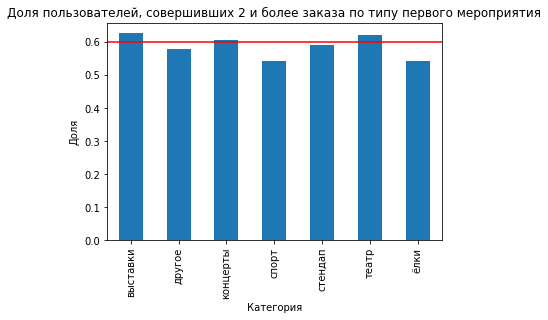

In [72]:
(df_new2[['event_type_main', 'is_two']].groupby('event_type_main').sum()/df_new2[['event_type_main', 'is_two']].groupby('event_type_main').count()).plot(kind = 'bar',
title = 'Доля пользователей, совершивших 2 и более заказа по типу первого мероприятия',
xlabel = 'Категория',
ylabel = 'Доля',
legend = False)
plt.axhline(y=df_new2['is_two'].mean(), color='red')
plt.show()

Вывод: чаще всего возвращаются те пользователи, которые впервые приобретают билеты на выставку (63%) / в театр (62%) и на концерты (61%)
Реже всего - на спорт / на елки - 54%
Средний показатель возврата пользователей составляет 59,9%

In [73]:
round(df_new2['is_two'].mean(), 3)

0.599

In [74]:
df_new2[['device', 'is_two']].groupby('device').sum()/df_new2[['device', 'is_two']].groupby('device').count()

,is_two
device,
desktop,0.622023
mobile,0.593813


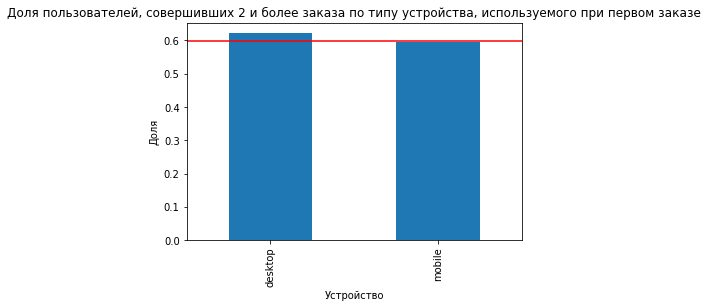

In [75]:
(df_new2[['device', 'is_two']].groupby('device').sum()/df_new2[['device', 'is_two']].groupby('device').count()).plot(kind = 'bar',
title = 'Доля пользователей, совершивших 2 и более заказа по типу устройства, используемого при первом заказе',
xlabel = 'Устройство',
ylabel = 'Доля',
legend = False)
plt.axhline(y=df_new2['is_two'].mean(), color='red')
plt.show()

Вывод: чаще (хоть и незначительно) возвращаются пользователи, сделавшие заказ с ПК

In [76]:
top_rg = df_new2['region'].value_counts().head(10)

In [77]:
filtr1 = top_rg.reset_index()['index'].values

In [78]:
df_toprg = df_new2[df_new2['region'].isin(filtr1)]

In [79]:
for_plt = (df_toprg[['region', 'is_two']].groupby('region').sum()/df_toprg[['region', 'is_two']].groupby('region').count()).sort_values(by = 'is_two', ascending = False)

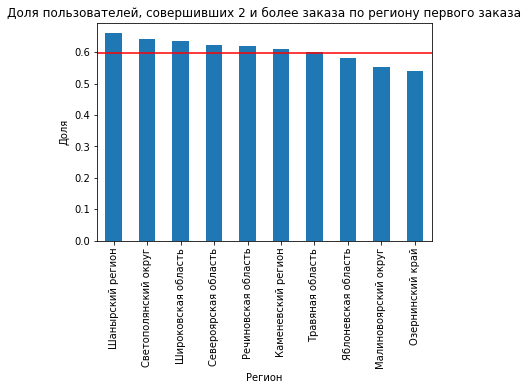

In [80]:
for_plt.head(10).plot(kind = 'bar',
title = 'Доля пользователей, совершивших 2 и более заказа по региону первого заказа',
xlabel = 'Регион',
ylabel = 'Доля',
legend = False)
plt.axhline(y=df_new2['is_two'].mean(), color='red')
plt.show()

In [81]:
top_rg

Каменевский регион      6841
Североярская область    3599
Широковская область     1193
Озернинский край         663
Малиновоярский округ     522
Шанырский регион         470
Травяная область         470
Светополянский округ     441
Речиновская область      419
Яблоневская область      401
Name: region, dtype: int64

Вывод: данные распределены неравномерно, не совсем корректно сравнивать регионы с количеством заказов, превышающим 7 тысяч и регионы с несколькими сотнями заказов - у последних "чувствительность" выше.
Однако, чаще всего возвращаются пользователи, сделавшие первый заказ в шанырском регионе, реже всего - в озеринском крае

In [82]:
top_service = df_new2['service_name'].value_counts().head(10)

In [83]:
filtr2 = top_service.reset_index()['index'].values

In [84]:
df_topserv = df_new2[df_new2['service_name'].isin(filtr2)]

In [85]:
for_plt2 = (df_topserv[['service_name', 'is_two']].groupby('service_name').sum()/df_topserv[['service_name', 'is_two']].groupby('service_name').count()).sort_values(by = 'is_two', ascending = False)

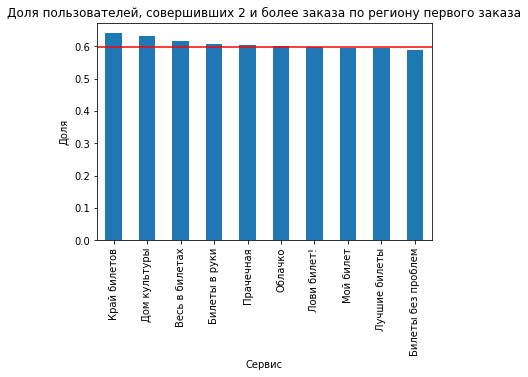

In [86]:
for_plt2.head(10).plot(kind = 'bar',
title = 'Доля пользователей, совершивших 2 и более заказа по региону первого заказа',
xlabel = 'Сервис',
ylabel = 'Доля',
legend = False)
plt.axhline(y=df_new2['is_two'].mean(), color='red')
plt.show()

In [87]:
top_service

Билеты без проблем    4985
Мой билет             2884
Лови билет!           2715
Билеты в руки         2424
Облачко               2113
Весь в билетах        1248
Лучшие билеты         1130
Прачечная              554
Край билетов           442
Дом культуры           339
Name: service_name, dtype: int64

In [88]:
for_plt2

,is_two
service_name,
Край билетов,0.640271
Дом культуры,0.631268
Весь в билетах,0.615385
Билеты в руки,0.607261
Прачечная,0.604693
Облачко,0.601988
Лови билет!,0.596685
Мой билет,0.595354
Лучшие билеты,0.594690


Вывод: распределение заказов по сервисам также неравномерно, корректность сравнения различных сервисов под вопросом из-за разной "чувствительности" категорий (возврат одного пользователя из 400 изменит долю возвратов значительнее, чем возврат одного пользователя из 6000)

Чаще возвращаются пользователи, которые приобрели первый билет в "Край билетов", реже - "Билеты без проблем", однако ко второму сервису обратилось почти в 10 раз больше пользователей, чем к первому
В целом распределение не сильно отклоняется от среднего значения возвратов пользователей

ВЫВОД: можно отметить 2 типа мероприятий, возврат по которым наименьший - спорт и елки (всего 54%). Чаще возвращаются те пользователи, которые оформили свой первый заказ с ПК, те, кто сделал это в Шанырском регионе и через сервис "Край билетов"

Однако практически везде пользователи распределены по категориям неравномерно, что не дает сделать однозначных выводов при анализе

Отклонения от средних значений не превышают 5% по всем сегментам, поэтому ярковыраженных "успешных" точек входа нет

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1: доля возвратов действительно зависит от типа мероприятия, но лояльных пользователей, которые приобрели билет на концерт в первом заказе на 7% больше, чем лояльных пользователей, которые купили билеты на спорт. Кроме того, доля лояльных пользователей, впервые посетивших спортивное мероприятие, отклоняется от среднего значения по возвратам на 5%



Гипотеза НЕ ВЕРНА

Гипотеза 2: ранее уже отмечалось неравномерное распределение данных: чем больше пользователей в сегменте, тем ниже "чувствительность данных". Поэтому возврат пользователя в сегменте с меньшим числом заказов - событие априори "ГРАНДИОЗНЕЕ", чем возврат пользователя в сегменте, где заказов много. Данные подтверждают: сервису "Билеты без проблем" (4985 заказов) соответствует значение в 59% возвратов, а сервису "Край билетов" (442 заказов) - 64%


Гипотеза НЕ ВЕРНА

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [89]:
group_one = df_new2[df_new2['total_cnt'] == 1]
group_two = df_new2[df_new2['is_two'] == True]

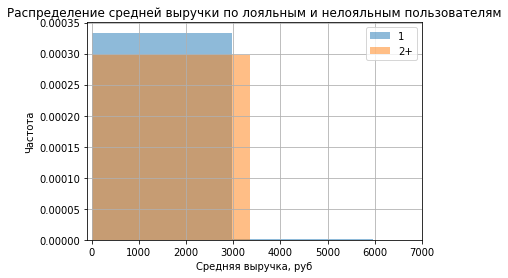

In [90]:
group_one['revenue_rub'].hist(bins = 5,
                             alpha = 0.5,
                             density = True,
                             label = '1')

group_two['revenue_rub'].hist(bins = 5,
                             alpha = 0.5,
                             density = True,
                             label = '2+')
plt.xlim(-100, 7000)
plt.legend()
plt.title('Распределение средней выручки по лояльным и нелояльным пользователям')
plt.ylabel("Частота")
plt.xlabel("Средняя выручка, руб")

plt.show()

Средняя выручка по первому заказу у лояльных клиентов распределена в основном от 0 до ~3200. Средняя выручка с первого заказа у НЕлояльных в основном - от 0 до 3000.  

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [91]:
group_twofour = df_new2[(df_new2['total_cnt'] >=2) & (df_new2['total_cnt'] <=4)]
group_five = df_new2[df_new2['is_five'] == True]

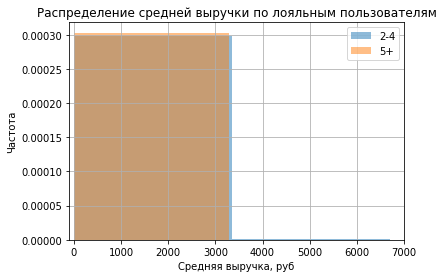

In [92]:
group_twofour['revenue_rub'].hist(bins = 5,
                             alpha = 0.5,
                             density = True,
                             label = '2-4')

group_five['revenue_rub'].hist(bins = 5,
                             alpha = 0.5,
                             density = True,
                             label = '5+')
plt.xlim(-100, 7000)
plt.legend()
plt.title('Распределение средней выручки по лояльным пользователям')
plt.ylabel("Частота")
plt.xlabel("Средняя выручка, руб")

plt.show()

Различия незначтельные: средняя выручка с первого заказа у пользователей с 2-4 заказами незначительно, чем этот показатель у пользователей с 5+ заказами

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

([<matplotlib.axis.XTick at 0x7f3546adaa30>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

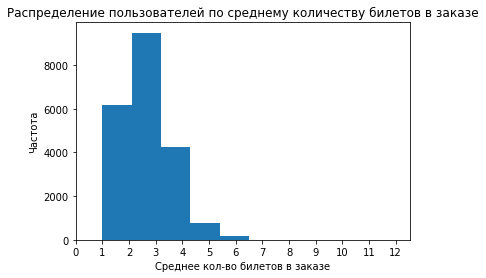

In [93]:
df_new2['avg_tickets'].plot(kind = 'hist')

plt.title('Распределение пользователей по среднему количеству билетов в заказе')
plt.ylabel('Частота')
plt.xlabel('Среднее кол-во билетов в заказе')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12])

В среднем в заказе пользователя встречается от 2х до 3х билетов

Основное распределение все же охватывает значения от 1 до 6,5 билетов

In [94]:
seg12 = df_new2[(df_new2['avg_tickets'] >= 1) & (df_new2['avg_tickets']< 2)]
seg23 = df_new2[(df_new2['avg_tickets'] >= 2) & (df_new2['avg_tickets']< 3)]
seg35 = df_new2[(df_new2['avg_tickets'] >= 3) & (df_new2['avg_tickets']< 5)]
seg5 = df_new2[df_new2['avg_tickets'] >= 5]

In [95]:
seg122 = seg12[seg12['is_two'] == True]
seg232 = seg23[seg23['is_two'] == True]
seg352 = seg35[seg35['is_two'] == True]
seg52 = seg5[seg5['is_two'] == True]

In [96]:
cnts = [len(seg12), len(seg23), len(seg35), len(seg5)]
cnts2 = [round(len(seg122)/len(seg12), 2), round(len(seg232)/len(seg23), 2), round(len(seg352)/len(seg35), 2), round(len(seg52)/len(seg5), 2)]
names = ['1-2', '2-3', '3-5', '5+']

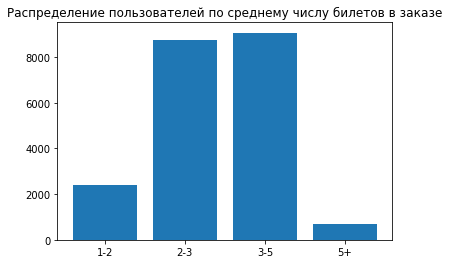

In [97]:
plt.bar(names, cnts)

plt.title('Распределение пользователей по среднему числу билетов в заказе')
plt.show()

Вывод: чаще всего пользователи приобретают в среднем 3-5 билета

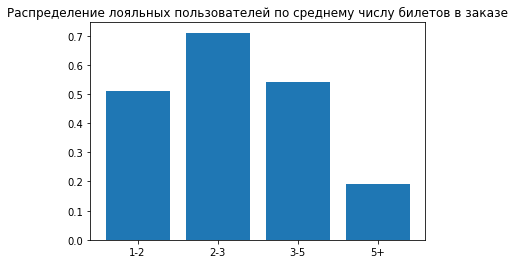

In [98]:
plt.bar(names, cnts2)

plt.title('Распределение лояльных пользователей по среднему числу билетов в заказе')
plt.show()

Вывод: чаще всего возвращаются пользователи, которые приобретают в среднем 2-3 билета

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [99]:
df_new2_cp = df_new2.copy()

In [100]:
df_new2_cp['weekday'] = df_new2['first_order_dt'].dt.weekday

In [101]:
table1 = df_new2_cp[['user_id', 'weekday', 'is_two']].groupby('weekday').agg({'user_id': 'count', 'is_two' : 'mean'})

In [102]:
names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
total = table1['user_id']
dolya = table1['is_two']

Text(0.5, 1.0, 'Количество первых заказов пользователей в зависимости от дня недели')

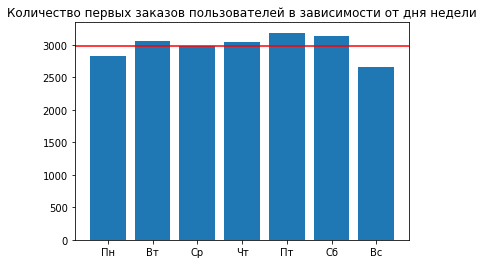

In [103]:
plt.bar(names, total)

plt.axhline(y = table1['user_id'].mean(), color = 'red')
plt.title('Количество первых заказов пользователей в зависимости от дня недели')

Text(0.5, 1.0, 'Доля возвратов пользователей в зависимости от дня недели их первого заказа')

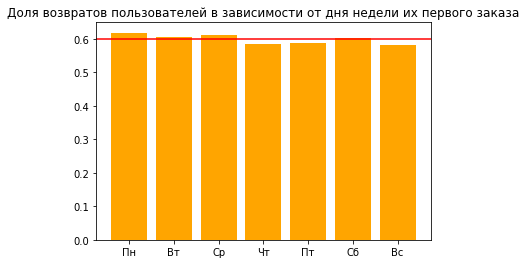

In [104]:
plt.bar(names, dolya, color = 'orange')
plt.axhline(y = table1['is_two'].mean(), color = 'red')
plt.title('Доля возвратов пользователей в зависимости от дня недели их первого заказа')

Вывод: реже всего пользователи делают заказы в понедельник и воскресенье, чаще - в пятницу и субботу. 

Незначительное отличие в распределении долей возврата пользователей в зависимости от дня недели. Реже возвращаются пользователи, сделавшие первый заказ в чт, пт и вс. Чаще - в пн и ср.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [105]:
round(group_twofour['avg_days'].mean(), 2)

21.33

In [106]:
round(group_five['avg_days'].mean(), 2)

11.14

Чем меньше средний интервал между заказами, тем выше вероятность повторного заказа. В группе с 5 и более заказами средний интервал в 2 раза меньше, чем в группе с 2-4

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [107]:
interval_columns = ['avg_tickets', 'revenue_rub', 'avg_days', 'total_cnt']
analyse_cols = ['first_order_dt', 'last_order_dt', 'device', 'region', 'service_name', 'event_type_main', 'avg_tickets', 'revenue_rub', 'avg_days', 'total_cnt', 'is_two', 'is_five', 'weekday']

In [109]:
phik_matrix = df_new2_cp[analyse_cols].phik_matrix(interval_cols = interval_columns)

In [110]:
phik_matrix['total_cnt']

first_order_dt     0.388742
last_order_dt      0.393659
device             0.036761
region             0.000000
service_name       0.040295
event_type_main    0.030403
avg_tickets        0.314573
revenue_rub        0.048460
avg_days           0.467306
total_cnt          1.000000
is_two             0.618740
is_five            1.000000
weekday            0.021037
Name: total_cnt, dtype: float64

<AxesSubplot:>

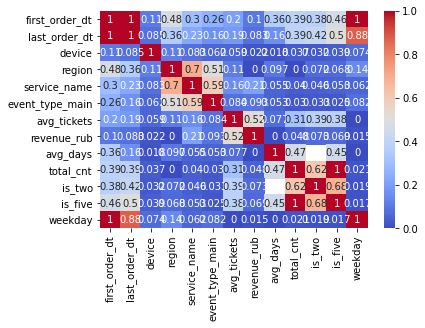

In [111]:
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm')

In [112]:
def ord_seg(i):
    if i == 1:
        return '1 заказ'
    elif (2 <= i) & (i <= 4):
        return '2 - 4 заказа'
    elif i >= 5:
        return '5+ заказов'

In [113]:
df_new2_cp['segment'] = df_new2_cp['total_cnt'].apply(ord_seg)

In [114]:
analyse_cols1 = ['first_order_dt', 'last_order_dt', 'device', 'region', 'service_name', 'event_type_main', 'avg_tickets', 'revenue_rub', 'avg_days', 'segment', 'is_two', 'is_five', 'weekday']

In [115]:
interval_columns1 = ['avg_tickets', 'revenue_rub', 'avg_days']

In [116]:
phik_matrix_new = df_new2_cp[analyse_cols1].phik_matrix(interval_cols = interval_columns1)

<AxesSubplot:>

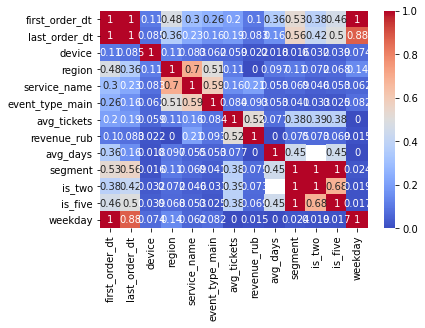

In [117]:
sns.heatmap(phik_matrix_new, annot=True, cmap='coolwarm')

In [118]:
phik_matrix_new['segment']

first_order_dt     0.527300
last_order_dt      0.560144
device             0.015817
region             0.105754
service_name       0.069382
event_type_main    0.041120
avg_tickets        0.377602
revenue_rub        0.074654
avg_days           0.448562
segment            1.000000
is_two             1.000000
is_five            1.000000
weekday            0.024141
Name: segment, dtype: float64

Вывод: с первой и последней датой заказа корреляция ~0,53-0,56, связь достаточно сильная. Наблюдается корреляция со средним количеством дней и средним числом билетов в заказе (0,45 и 0,38 соответственно).
С регионом, названием сервиса, типом события, днем недели и выручкой корреляция очень слабая (от 0,02 до 0,11).

С бинарными признаками корреляция = 1

С количеством заказов наиболее связаны следующие признаки: дата заказа, среднее количество дней между заказами и среднее число билетов

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В ходе проекта была проведена работа с данными с сайта Яндекс Афиша (сервис для покупки билетов на мероприятия). В результате предобработки:
- Проведена оптимизация типов данных (снижена размерность) и проверка их качества (ошибок в названиях столбцов не обнаружено, выдержан единый стиль snake_case, категориальные данные также корректны. Были найдены пропуски в столбце с разницей между заказами пользователя в днях, однако было принято решение не устранять их, т.к. они важны для дальнейшего анализа). 
- Рассчитана выручка в рублях с учетом ежедневного курса валюты (тенге к рублю). Выполнена очистка от аномалий: удалены отрицательные значения и выбросы выше 99-го перцентиля. Итоговый датасет сохранил 98,8% исходных строк.

Далее был сформирован профиль пользователя, куда вошло 21832 строк с информацией о первом заказе пользователя, аггрегированными показателями и бинарными столбцами (is_two для вернувшихся пользователей, совершивших 2 и более заказа и is_five для постоянных покупателей с 5 и более заказами)

Далее данные были отсортированы по 95 перцентилю по количеству заказов для минимизации выбросов, в результате осталось 20763 строки (уникальных пользователя)

Пользователи распределены следующим образом:
- По категориям событий: концерты выбирают 44,4% пользователей. Второе и третье место занимают категории «другое» (24,8%) и театр (19,6%). На остальные типы мероприятий (стендап, спорт, выставки и ёлки) суммарно приходится около 11% аудитории. 
- По устройствам: 83% пользователей совершают заказы через мобильные устройства, и только 17% используют ПК
- По регионам: 33% пользователей сделали свой первый заказ из каменевского региона, а из Светолесского, Верхозёрского края, Яснопольского округа и Сосноводолинской области только 0.0048%
- По сервису: 23% билетов было куплено пользователем на афише впервые через сервис "Билеты без проблем" и только 0.0048% через сервис "Зе Бест!" 
Т.е. пользователи по сегментам распределены НЕравномерно, есть "успешные" точки входа: мобильный заказ, билет на концерт, каменевский район, сервис "Билеты без проблем"

С возвратом пользователей связаны следующие признаки первого заказа:
- Средняя выручка (распределена "компактнее" у нелояльных пользователей)
- Среднее количество билетов в заказе (чаще возвращаются те, кто приобрел в среднем 2-3 билета)
- День недели заказа (реже всего пользователи делают заказы в понедельник и воскресенье, чаще - в пятницу и субботу)
- Промежуток между заказами (чем дольше среднее время между заказами, тем меньше их количество)

Согласно результатам корреляционного анализа, с числом покупок могут быть связаны следующие признаки: 
- Первая и последняя дата заказа, среднее количество дней и среднее число билетов в заказе
- И в меньшей степени: регион, название сервиса, тип события, день недели и выручка 

Рекомендаци. В данной ситуации необходимо обратить внимание на:
- категории мероприятий (повысить охваты на стендап, спорт, выставки и ёлки (последнее сезонно))
- дни недели заказов (акции по понедельникам и воскресеньям)
- сервисы для заказа билетов (дополнительная поддержка для непопулярных сервисов)
- регионы заказов (акции для непопулярных регионов)

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**